FreshMart Spending Analysis
Nicholas, Jacque, Matthew

In [1]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Part 1

In [2]:
# 4
spend_df = pd.read_csv('./data/freshmart_spend.csv')

In [3]:
# 5
print(spend_df.head(10))
spend_df.info()
spend_df.describe()
spend_df.tail(10)

      group      spend
0  App User  65.450712
1  App User  55.926035
2  App User  67.715328
3  App User  80.845448
4  App User  54.487699
5  App User  54.487946
6  App User  81.688192
7  App User  69.511521
8  App User  50.957884
9  App User  66.138401
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   group   400 non-null    object 
 1   spend   400 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.4+ KB


,group,spend
390,Non-User,38.523780
391,Non-User,59.378788
392,Non-User,32.196502
393,Non-User,79.471881
394,Non-User,69.691602
395,Non-User,44.962365
396,Non-User,26.302982
397,Non-User,72.308086
398,Non-User,50.281902
399,Non-User,70.567245


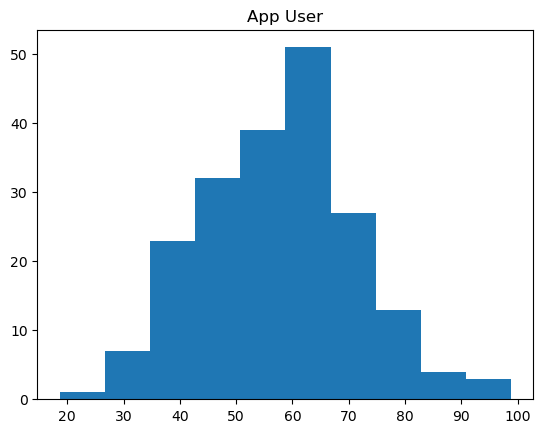

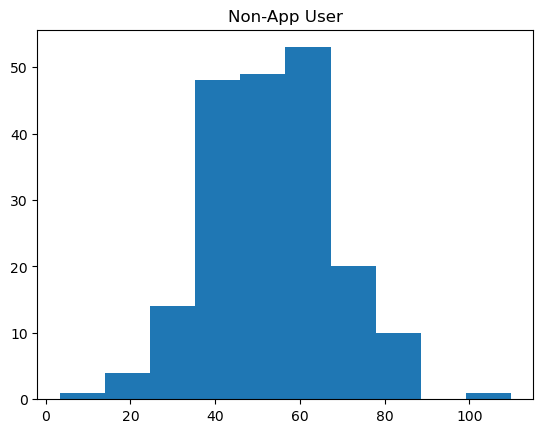

In [4]:
# 6
plt.hist(spend_df[spend_df['group'] == 'App User']['spend'])
plt.title("App User")
plt.show()
plt.hist(spend_df[spend_df['group'] == 'Non-User']['spend'])
plt.title("Non-App User")
plt.show()

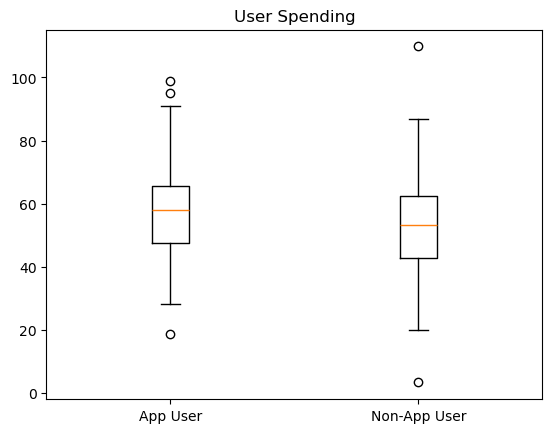

In [5]:
# 6
plt.boxplot([spend_df[spend_df['group'] == 'App User']['spend'],spend_df[spend_df['group'] == 'Non-User']['spend']], tick_labels=["App User", "Non-App User"])
plt.title("User Spending")
plt.show()

#7 
The distribution is centered around the middle of the histograms. The box plots are also evenly distributed between the wiskers and the lines. 
The distribution is normal.

# Part 2 
Hypothesis: μ₁ = μ₂
 App-User and Non-App users spend the same amount 

Alternative: μ₁ < μ₂
That the app users spend more

In [6]:
#2 Stats.TextDisplayObject
AppUser= spend_df[spend_df['group'] == 'App User']['spend']
NonUser= spend_df[spend_df['group'] == 'Non-User']['spend']
t_stat, p_val = stats.ttest_ind(AppUser, NonUser, equal_var= False)
print("T-Statistic:", t_stat)
print("P-Value:", p_val)

T-Statistic: 2.849252420752362
P-Value: 0.004610620601609663


In [7]:
#4/#5 DECIDE and EXPLAIN

#P is less than .05. The results are significant and demonstrate a difference between the Non-User and App User Group, showing that on average the app users spend $ 2.85 more than the non app users. 

# Part 3

In [8]:
# PART 3 - SIM Best/Worst Monthly Profit
# How much profit this month best/worst given average and our cost
app_user_mean = AppUser.mean()
app_user_std = AppUser.std()


In [9]:
# 1
non_user_mean = NonUser.mean()
non_user_std = NonUser.std()


In [10]:
# 2 - 5
def simulation_fresh(num_of_sims, app_user_mean, app_user_std, non_user_mean, non_user_std, user_mean_adjustment = 0, spending_modifier = 1, spending_variance = 0, num_app_users = 1000, num_non_app_users = 5000, fixed_cost = 292_000):
    total_profit = []
    for number in range(num_of_sims):
        simulated_sales_app = np.random.normal(app_user_mean + (user_mean_adjustment),app_user_std + (spending_variance), size=num_app_users)
        simulated_sales_non_app = np.random.normal(non_user_mean + (user_mean_adjustment), non_user_std + (spending_variance), size=num_non_app_users)
        sim_total_sales = (sum(simulated_sales_app)  + sum(simulated_sales_non_app)) * spending_modifier
        profit = sim_total_sales - fixed_cost
        total_profit.append(profit)
    return total_profit


The lower 5th percentile is 29945.74 and the 95th percentile is 33735.53
The average total revenue was: 31824.38


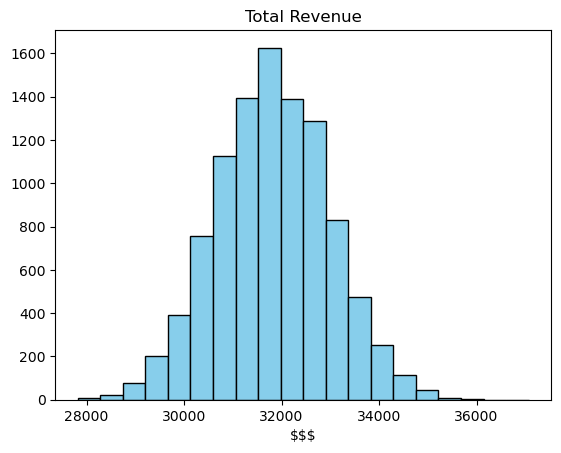

In [11]:

total_profit = simulation_fresh(10000, app_user_mean, app_user_std, non_user_mean, non_user_std)
upper = np.percentile(total_profit, 95)
lower = np.percentile(total_profit, 5)
print("The lower 5th percentile is", round(lower,2), "and the 95th percentile is", round(upper,2))
print("The average total revenue was:", round(np.mean(total_profit),2))

fig, ax = plt.subplots()
ax.hist(total_profit, bins=20, color = "skyblue", edgecolor ="black")
ax.set_title("Total Revenue")
ax.set_xlabel("$$$")
plt.show()


Based on the data, we can expect the customer to potentially spend between the amount listed above
Worst case is shown at the 5th percentile above. They could reasonably spend an additional $25,000 and still remain profitable.

# Advanced

The lower 5th percentile is -34.11 and the 95th percentile is 3730.66
The average total revenue was: 1835.2


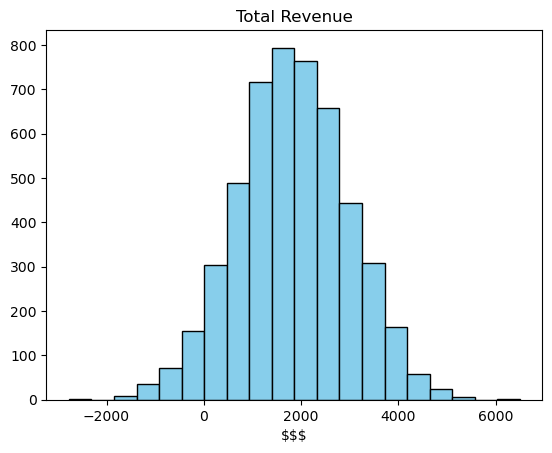

In [12]:
# $5 decrease in spending
decrease_profit = simulation_fresh(5000, app_user_mean, app_user_std, non_user_mean, non_user_std, -5)

upper = np.percentile(decrease_profit, 95)
lower = np.percentile(decrease_profit, 5)
print("The lower 5th percentile is", round(lower,2), "and the 95th percentile is", round(upper,2))
print("The average total revenue was:", round(np.mean(decrease_profit),2))

fig, ax = plt.subplots()
ax.hist(decrease_profit, bins=20, color = "skyblue", edgecolor ="black")
ax.set_title("Total Revenue")
ax.set_xlabel("$$$")
plt.show()

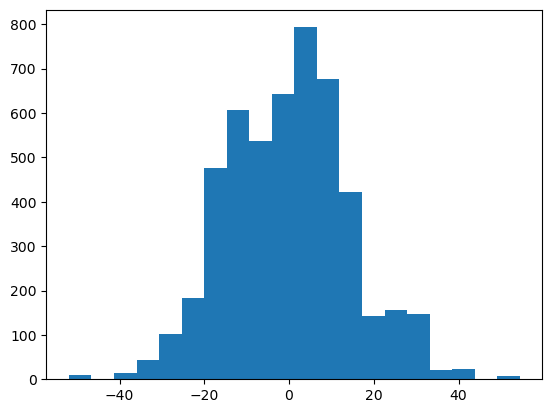

In [13]:
# Mean Difference
sample_mean = []
for i in range(5000):
    sample = np.random.choice(spend_df['spend'], size=1, replace=True)
    mn_avg = np.mean(sample)
    sample_mean.append(mn_avg - spend_df['spend'].mean())
plt.hist(sample_mean, bins=20)
plt.show()

In [14]:
#95% confidence interval for Mean Difference
sample_upper = np.percentile(sample_mean, 97.5)
sample_lower = np.percentile(sample_mean, 2.5)
sample_mean = pd.Series(sample_mean)
sample_confidence_interval = sample_mean[(sample_mean == sample_upper) & (sample_mean == sample_lower)]
print(f"The lower bound is {sample_lower}.\nThe upper bound is {sample_upper}.")

The lower bound is -26.73328102114757.
The upper bound is 29.508814835314155.


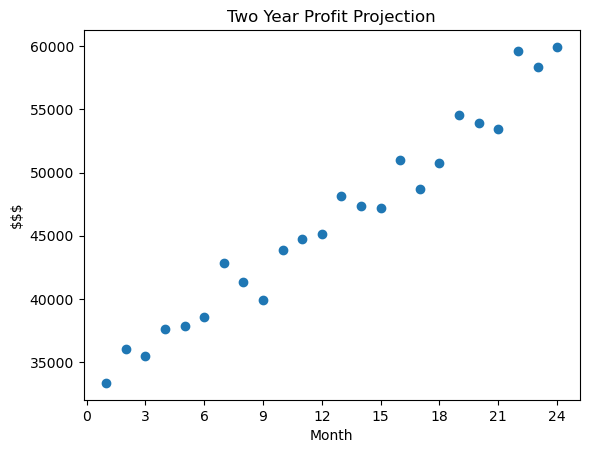

In [15]:
#Two Year Projection
months = 24
spending = 1
spending_growth = []
for i in range(months):
    if i % 3 == 0:
        spending += 0.01
    spending_growth.append(np.mean(simulation_fresh(1, app_user_mean, app_user_std, non_user_mean, non_user_std, spending_modifier=spending)))
plt.scatter(np.arange(1,25), spending_growth)
plt.xticks([0,3,6,9,12,15,18,21,24])
plt.title("Two Year Profit Projection")
plt.xlabel("Month")
plt.ylabel("$$$")
plt.show()

The lower 5th percentile is 30596.15 and the 95th percentile is 33011.01
The average total revenue was: 31830.84


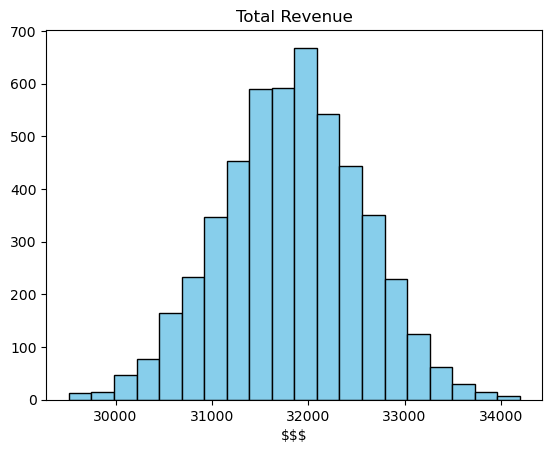

In [16]:
# Sensitivity Analysis
profit_variance = simulation_fresh(5000, app_user_mean, app_user_std, non_user_mean, non_user_std, spending_variance=-5)

upper = np.percentile(profit_variance, 95)
lower = np.percentile(profit_variance, 5)
print("The lower 5th percentile is", round(lower,2), "and the 95th percentile is", round(upper,2))
print("The average total revenue was:", round(np.mean(profit_variance),2))

fig, ax = plt.subplots()
ax.hist(profit_variance, bins=20, color = "skyblue", edgecolor ="black")
ax.set_title("Total Revenue")
ax.set_xlabel("$$$")
plt.show()